In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "/kaggle/input/cleaned-us-dataset-cdf/CFD 3.0 Norming Data and Codebook.xlsx"
df = pd.read_excel(file_path, sheet_name=1)

In [3]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Model,EthnicitySelf,GenderSelf,AgeSelf,AgeRated,Unnamed: 5,FemaleProb,MaleProb,AsianProb,ChineseAsianProb,...,EyeSize,UpperHeadLength,MidfaceLength,ChinLength,ForeheadHeight,CheekboneHeight,CheekboneProminence,FaceRoundness,fWHR2,RaterN
0,AF-200,A,F,NaN,32.571429,NaN,1.000000,0.000000,1.000000,NaN,...,0.060924,0.414099,0.326797,0.130719,0.264706,0.388189,91.5,0.545752,1.973890,28
1,AF-201,A,F,NaN,23.666667,NaN,1.000000,0.000000,0.962963,NaN,...,0.041892,0.414414,0.329279,0.144595,0.300901,0.383784,146.0,0.488288,2.068681,27
2,AF-202,A,F,NaN,24.448276,NaN,0.827586,0.172414,0.310345,NaN,...,0.051586,0.411080,0.310317,0.173424,0.298475,0.397029,58.0,0.481333,1.987261,29
3,AF-203,A,F,NaN,22.758621,NaN,1.000000,0.000000,0.758621,NaN,...,0.063913,0.354407,0.343793,0.169820,0.272266,0.421089,87.5,0.500231,1.902284,29
4,AF-204,A,F,NaN,30.137931,NaN,1.000000,0.000000,0.827586,NaN,...,0.053435,0.438931,0.293045,0.180237,0.293893,0.371925,73.5,0.513571,2.081081,29


In [4]:
df.shape



(597, 99)

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="5"


In [6]:
def linkfile(target):
    files = []
    file_count = 0
    path = "/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/%s/" % (target)
    for r, d, f in os.walk(path):
        for file in f: 
            if ('.jpg' in file) or ('.jpeg' in file) or '.png' in file:
                files.append(file)
    return files

In [7]:
# print(dataframe)
df["files"] = df.Model.apply(linkfile)


In [8]:
df[['Model', 'files']].head()


,Model,files
0,AF-200,[CFD-AF-200-228-N.jpg]
1,AF-201,[CFD-AF-201-060-N.jpg]
2,AF-202,[CFD-AF-202-122-N.jpg]
3,AF-203,[CFD-AF-203-077-N.jpg]
4,AF-204,[CFD-AF-204-067-N.jpg]


In [9]:
col = []

for i, inst in df.iterrows():
    folder = inst["Model"]   # <-- FIXED
    score = inst["Attractive"]      # still fine
    for file in inst["files"]:  # <-- FIXED
        tmp = []
        tmp.append(folder)
        tmp.append(file)
        tmp.append(score)
        col.append(tmp)


In [10]:
df2 = pd.DataFrame(col, columns = ["folder", "file", "score"])
df2[["folder",'file', 'score']].head()


,folder,file,score
0,AF-200,CFD-AF-200-228-N.jpg,4.111111
1,AF-201,CFD-AF-201-060-N.jpg,3.111111
2,AF-202,CFD-AF-202-122-N.jpg,3.000000
3,AF-203,CFD-AF-203-077-N.jpg,3.275862
4,AF-204,CFD-AF-204-067-N.jpg,3.172414


In [11]:
data = pd.concat([df, df2], axis=1)

data.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Model,EthnicitySelf,GenderSelf,AgeSelf,AgeRated,Unnamed: 5,FemaleProb,MaleProb,AsianProb,ChineseAsianProb,...,ForeheadHeight,CheekboneHeight,CheekboneProminence,FaceRoundness,fWHR2,RaterN,files,folder,file,score
0,AF-200,A,F,NaN,32.571429,NaN,1.000000,0.000000,1.000000,NaN,...,0.264706,0.388189,91.5,0.545752,1.973890,28.0,[CFD-AF-200-228-N.jpg],AF-200,CFD-AF-200-228-N.jpg,4.111111
1,AF-201,A,F,NaN,23.666667,NaN,1.000000,0.000000,0.962963,NaN,...,0.300901,0.383784,146.0,0.488288,2.068681,27.0,[CFD-AF-201-060-N.jpg],AF-201,CFD-AF-201-060-N.jpg,3.111111
2,AF-202,A,F,NaN,24.448276,NaN,0.827586,0.172414,0.310345,NaN,...,0.298475,0.397029,58.0,0.481333,1.987261,29.0,[CFD-AF-202-122-N.jpg],AF-202,CFD-AF-202-122-N.jpg,3.000000
3,AF-203,A,F,NaN,22.758621,NaN,1.000000,0.000000,0.758621,NaN,...,0.272266,0.421089,87.5,0.500231,1.902284,29.0,[CFD-AF-203-077-N.jpg],AF-203,CFD-AF-203-077-N.jpg,3.275862
4,AF-204,A,F,NaN,30.137931,NaN,1.000000,0.000000,0.827586,NaN,...,0.293893,0.371925,73.5,0.513571,2.081081,29.0,[CFD-AF-204-067-N.jpg],AF-204,CFD-AF-204-067-N.jpg,3.172414


In [12]:
data.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Model,EthnicitySelf,GenderSelf,AgeSelf,AgeRated,Unnamed: 5,FemaleProb,MaleProb,AsianProb,ChineseAsianProb,...,ForeheadHeight,CheekboneHeight,CheekboneProminence,FaceRoundness,fWHR2,RaterN,files,folder,file,score
0,AF-200,A,F,NaN,32.571429,NaN,1.000000,0.000000,1.000000,NaN,...,0.264706,0.388189,91.5,0.545752,1.973890,28.0,[CFD-AF-200-228-N.jpg],AF-200,CFD-AF-200-228-N.jpg,4.111111
1,AF-201,A,F,NaN,23.666667,NaN,1.000000,0.000000,0.962963,NaN,...,0.300901,0.383784,146.0,0.488288,2.068681,27.0,[CFD-AF-201-060-N.jpg],AF-201,CFD-AF-201-060-N.jpg,3.111111
2,AF-202,A,F,NaN,24.448276,NaN,0.827586,0.172414,0.310345,NaN,...,0.298475,0.397029,58.0,0.481333,1.987261,29.0,[CFD-AF-202-122-N.jpg],AF-202,CFD-AF-202-122-N.jpg,3.000000
3,AF-203,A,F,NaN,22.758621,NaN,1.000000,0.000000,0.758621,NaN,...,0.272266,0.421089,87.5,0.500231,1.902284,29.0,[CFD-AF-203-077-N.jpg],AF-203,CFD-AF-203-077-N.jpg,3.275862
4,AF-204,A,F,NaN,30.137931,NaN,1.000000,0.000000,0.827586,NaN,...,0.293893,0.371925,73.5,0.513571,2.081081,29.0,[CFD-AF-204-067-N.jpg],AF-204,CFD-AF-204-067-N.jpg,3.172414


In [13]:
# Convert both columns to string type before concatenating
data['file'] = ("/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/" + 
                data["folder"].astype(str) + 
                "/" + 
                data['file'].astype(str))

In [14]:
from tqdm import tqdm
tqdm.pandas()
from tensorflow.keras.preprocessing import image

def retrievePixels(path):
    # Use color_mode='rgb' instead of grayscale=False
    img = image.load_img(path, color_mode='rgb', target_size=(224, 224))
    x = image.img_to_array(img)
    return x

2025-09-07 17:22:06.626223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757265726.809703      18 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757265726.864786      18 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [15]:
data['pixels'] = data['file'].progress_apply(retrievePixels)


100%|██████████| 1207/1207 [01:04<00:00, 18.81it/s]


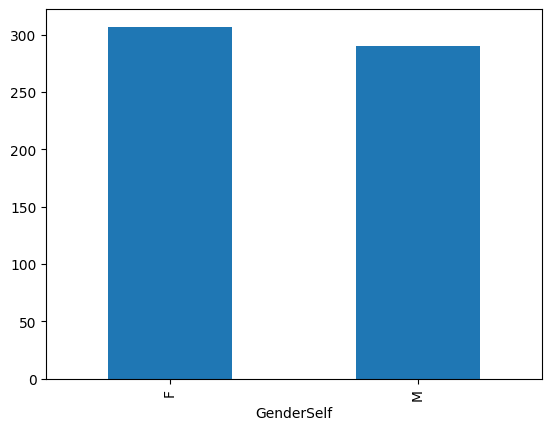

In [16]:
data['GenderSelf'].value_counts().plot(kind='bar')
plt.show()


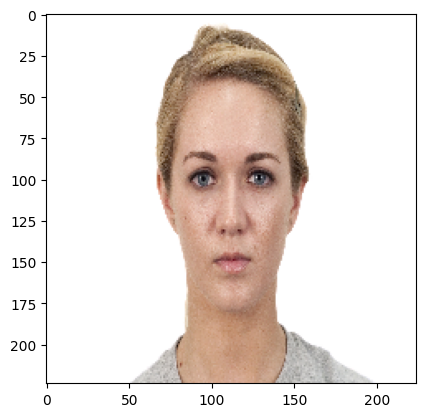

/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/WF-233/CFD-WF-233-112-N.jpg
Attractiveness score:  5.47826087


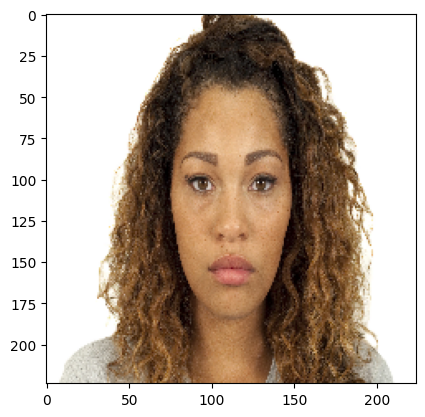

/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/BF-240/CFD-BF-240-179-N.jpg
Attractiveness score:  5.310344828


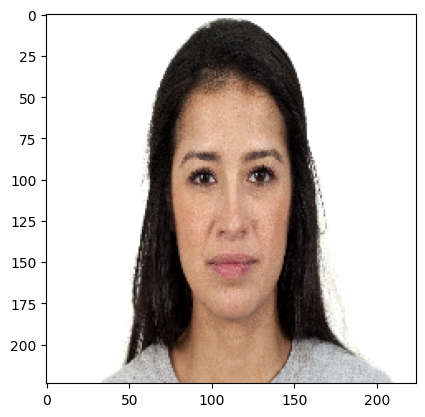

/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/LF-249/CFD-LF-249-132-N.jpg
Attractiveness score:  5.24137931


In [17]:
# top 3 most score faces
for i,pic in data.sort_values(by=['score'], ascending = False).head(3).iterrows():
    img = pic.pixels
    img = img.reshape(224, 224, 3)
    img = img / 255
    
    plt.imshow(img)
    plt.show()
    print(pic.file)
    print("Attractiveness score: ",pic.score)

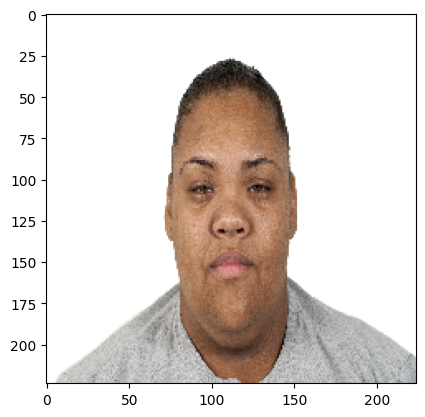

/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/BF-200/CFD-BF-200-080-N.jpg
Attractiveness score:  1.551724138


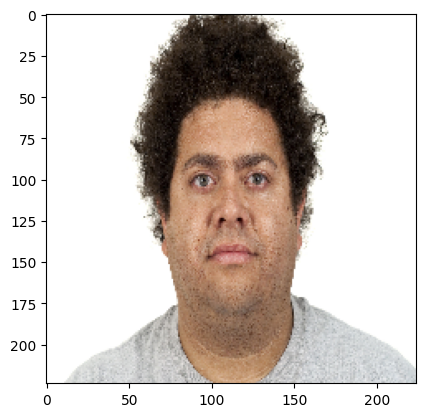

/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/LM-240/CFD-LM-240-013-N.jpg
Attractiveness score:  1.541666667


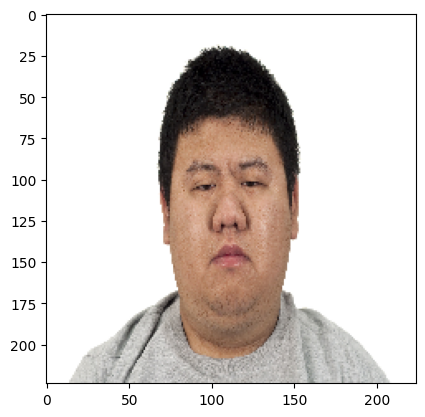

/kaggle/input/cdf-face-dataset-3-0-zip/cfd/CFD Version 3.0/Images/CFD/AM-224/CFD-AM-224-126-N.jpg
Attractiveness score:  1.52


In [18]:
# least attractivness score
for i,pic in data.sort_values(by=['score'], ascending = False).tail(3).iterrows():
    img = pic.pixels
    img = img.reshape(224, 224, 3)
    img = img / 255
    
    plt.imshow(img)
    plt.show()
    print(pic.file)
    print("Attractiveness score: ",pic.score)

In [19]:
features = []
pixels = data['pixels'].values

In [20]:
for i in range(0, pixels.shape[0]):
    features.append(pixels[i])

In [21]:
features = np.array(features)
features = features.reshape(features.shape[0], 224, 224, 3)
features = features / 255

In [22]:
features.shape


(1207, 224, 224, 3)

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, data.score.values, test_size=0.2, random_state=21)
print("train set: ", x_train.shape[0])
print("validation set: ", x_test.shape[0])

train set:  965
validation set:  242


In [24]:
import keras
from keras.callbacks import ModelCheckpoint,EarlyStopping
from keras.layers import Conv2D, AveragePooling2D
from keras.models import Model, Sequential
from keras.layers import Dense, Activation, Dropout, Flatten
from keras.layers import Input, Convolution2D,ZeroPadding2D, MaxPooling2D, Activation

In [25]:
model = Sequential()
model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))
 
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))
 
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(256, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(256, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))
 
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))
 
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))
 
model.add(Convolution2D(4096, (7, 7), activation='relu'))
model.add(Dropout(0.5))
model.add(Convolution2D(4096, (1, 1), activation='relu'))
model.add(Dropout(0.5))
model.add(Convolution2D(2622, (1, 1)))
model.add(Flatten())
model.add(Activation('softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-09-07 17:23:25.671151: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [26]:
model.load_weights('/kaggle/input/vgg-face-weightsh5/vgg_face_weights.h5')


In [27]:
from keras.models import Model
from keras.layers import Input, Convolution2D, ZeroPadding2D, MaxPooling2D, Flatten, Dense, Dropout, Activation

def vgg_face(weights_path=None):
    """
    Builds the VGG-Face model architecture.
    
    Args:
        weights_path (str, optional): Path to the weights file. Defaults to None.
        
    Returns:
        keras.models.Model: The VGG-Face model.
    """
    # Define the input tensor
    img = Input(shape=(224, 224, 3))

    # Block 1
    pad1_1 = ZeroPadding2D(padding=(1, 1))(img)
    conv1_1 = Convolution2D(64, (3, 3), activation='relu', name='conv1_1')(pad1_1)
    pad1_2 = ZeroPadding2D(padding=(1, 1))(conv1_1)
    conv1_2 = Convolution2D(64, (3, 3), activation='relu', name='conv1_2')(pad1_2)
    pool1 = MaxPooling2D((2, 2), strides=(2, 2))(conv1_2)

    # Block 2
    pad2_1 = ZeroPadding2D(padding=(1, 1))(pool1)
    conv2_1 = Convolution2D(128, (3, 3), activation='relu', name='conv2_1')(pad2_1)
    pad2_2 = ZeroPadding2D(padding=(1, 1))(conv2_1)
    conv2_2 = Convolution2D(128, (3, 3), activation='relu', name='conv2_2')(pad2_2)
    pool2 = MaxPooling2D((2, 2), strides=(2, 2))(conv2_2)

    # Block 3
    pad3_1 = ZeroPadding2D(padding=(1, 1))(pool2)
    conv3_1 = Convolution2D(256, (3, 3), activation='relu', name='conv3_1')(pad3_1)
    pad3_2 = ZeroPadding2D(padding=(1, 1))(conv3_1)
    conv3_2 = Convolution2D(256, (3, 3), activation='relu', name='conv3_2')(pad3_2)
    pad3_3 = ZeroPadding2D(padding=(1, 1))(conv3_2)
    conv3_3 = Convolution2D(256, (3, 3), activation='relu', name='conv3_3')(pad3_3)
    pool3 = MaxPooling2D((2, 2), strides=(2, 2))(conv3_3)

    # Block 4
    pad4_1 = ZeroPadding2D(padding=(1, 1))(pool3)
    conv4_1 = Convolution2D(512, (3, 3), activation='relu', name='conv4_1')(pad4_1)
    pad4_2 = ZeroPadding2D(padding=(1, 1))(conv4_1)
    conv4_2 = Convolution2D(512, (3, 3), activation='relu', name='conv4_2')(pad4_2)
    pad4_3 = ZeroPadding2D(padding=(1, 1))(conv4_2)
    conv4_3 = Convolution2D(512, (3, 3), activation='relu', name='conv4_3')(pad4_3)
    pool4 = MaxPooling2D((2, 2), strides=(2, 2))(conv4_3)

    # Block 5
    pad5_1 = ZeroPadding2D(padding=(1, 1))(pool4)
    conv5_1 = Convolution2D(512, (3, 3), activation='relu', name='conv5_1')(pad5_1)
    pad5_2 = ZeroPadding2D(padding=(1, 1))(conv5_1)
    conv5_2 = Convolution2D(512, (3, 3), activation='relu', name='conv5_2')(pad5_2)
    pad5_3 = ZeroPadding2D(padding=(1, 1))(conv5_2)
    conv5_3 = Convolution2D(512, (3, 3), activation='relu', name='conv5_3')(pad5_3)
    pool5 = MaxPooling2D((2, 2), strides=(2, 2))(conv5_3)
    
    # --- THIS IS THE CORRECTED SECTION ---
    # The first fully-connected layer is implemented as a convolution
    fc6 = Convolution2D(4096, (7, 7), activation='relu', name='fc6')(pool5)
    fc6_drop = Dropout(0.5)(fc6)
    
    # The second fully-connected layer is also a convolution (1x1)
    fc7 = Convolution2D(4096, (1, 1), activation='relu', name='fc7')(fc6_drop)
    fc7_drop = Dropout(0.5)(fc7)

    # The output layer is a 1x1 convolution followed by a Flatten and Softmax
    fc8 = Convolution2D(2622, (1, 1), name='fc8')(fc7_drop)
    flat = Flatten()(fc8)
    out = Activation('softmax')(flat)
    # --- END OF CORRECTION ---

    # Create the Keras model
    model = Model(inputs=img, outputs=fc8)
    
    # Load the weights if a path is provided
    if weights_path:
        model.load_weights(weights_path)
    
    return model

vgg_weights_path = '/kaggle/input/vgg-face-weightsh5/vgg_face_weights.h5' 
model = vgg_face(vgg_weights_path)


In [28]:
classes=1
for layer in model.layers[:-7]:
    layer.trainable = False

model_output = Sequential()
model_output = Flatten()(model.layers[-4].output)
model_output = Dense(classes)(model_output)
attractiveness_model = Model(inputs=model.input, outputs=model_output)


In [29]:
attractiveness_model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam())


In [30]:
score = attractiveness_model.fit(
    x_train, y_train,
    epochs=1,
    validation_data=(x_test, y_test)
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 586s 19s/step - loss: 10.7022 - val_loss: 0.4698


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt


In [32]:
predictions = attractiveness_model.predict(x_test)
actuals = y_test

8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step


In [33]:
perf = pd.DataFrame(actuals, columns = ["actuals"])
perf["predictions"] = predictions

In [34]:
print("mae: ", mean_absolute_error(actuals, predictions))
print("rmse: ", sqrt(mean_squared_error(actuals, predictions)))


mae:  0.5270769547992465
rmse:  0.6854102763756694


In [35]:
# Save the model to the output directory
attractiveness_model.save('/kaggle/working/attractiveness_model-cdf-us.h5')

print("Model saved successfully!")


Model saved successfully!
